# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


In [52]:
!pip install pandas
!pip install seaborn
!pip install numpy
!pip install matplotlib
!pip install missingno
!pip install plotly.express

## Imports des Bibliothèques


In [53]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [54]:
# Charger le dataset
df = pd.read_csv(r'C:\Users\Utilisateur\Desktop\e-commerce\Pipeline-ETL---Ingestion-transformation-et-chargement-de-donn-es-multi-sources\data\healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.03 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    str    
 3   email        300 non-null    str    
 4   start_date   300 non-null    str    
 5   end_date     300 non-null    str    
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 34.7 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

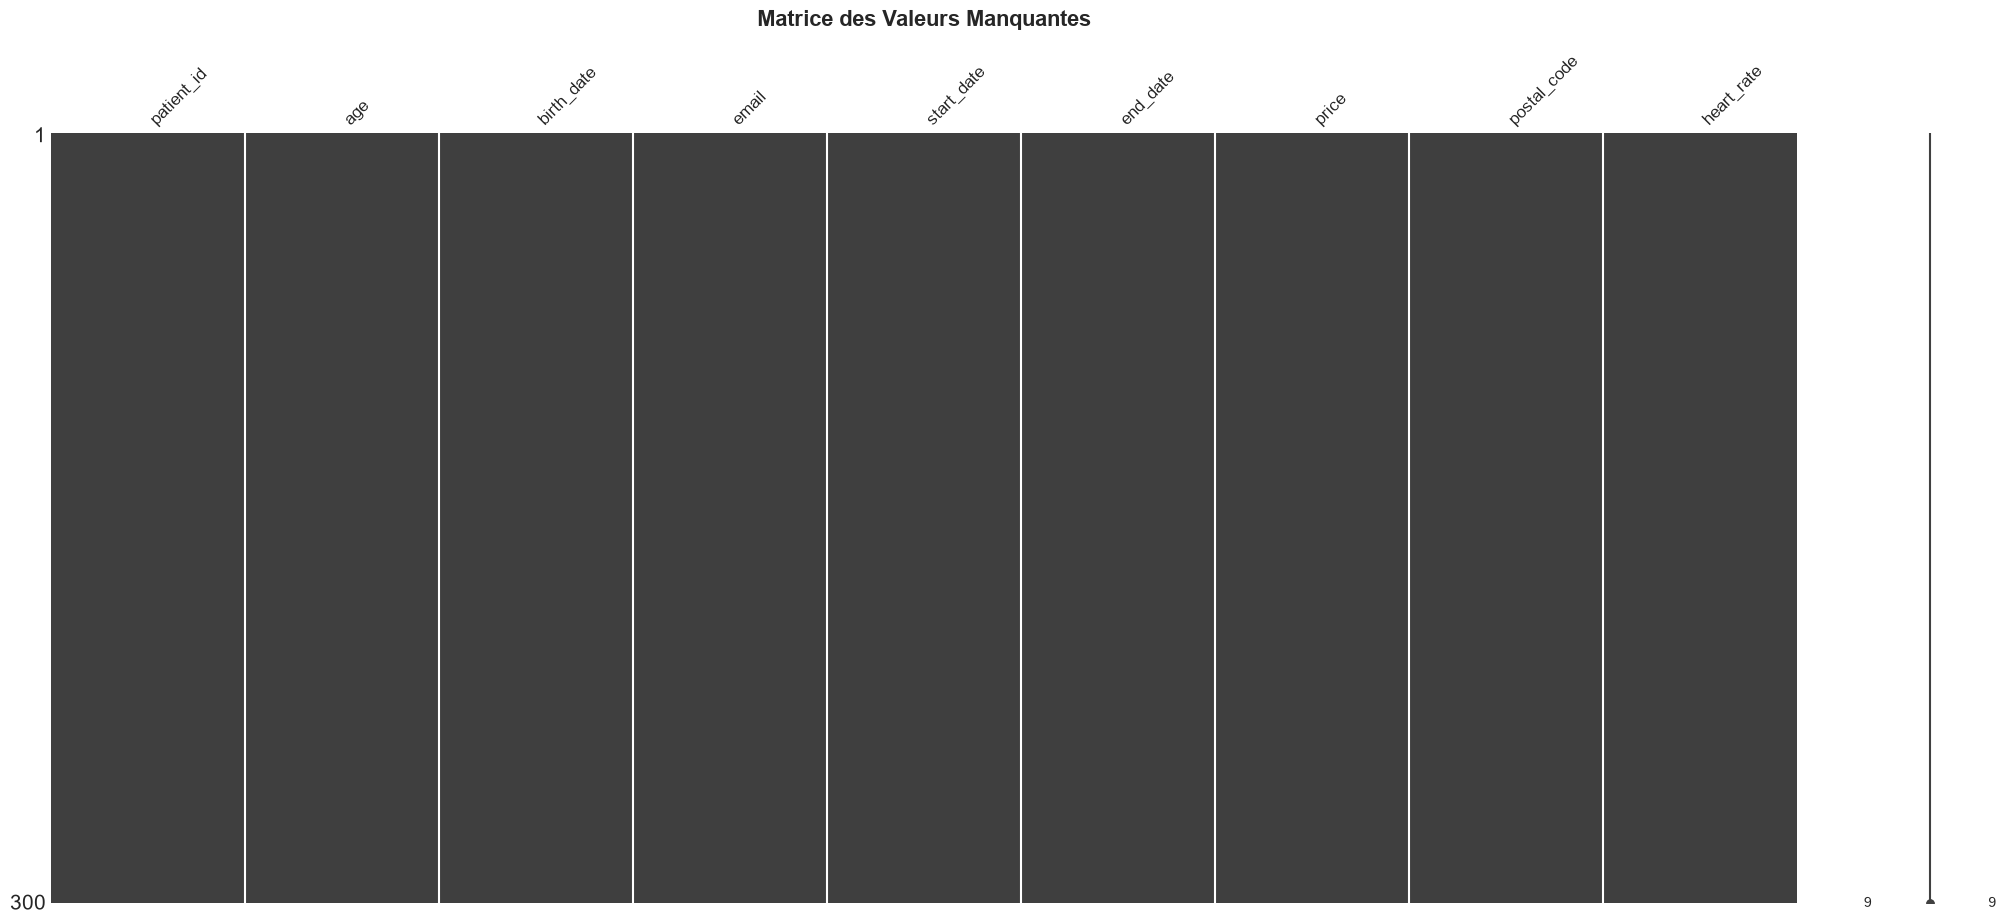


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [55]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [56]:
#1.Y a-t-il des âges négatifs ou supérieurs à 120 ans ?

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
invalid = (df[(df['age'] < 0) | (df['age'] > 120)])
len(invalid)



Réponses aux questions:


10

In [57]:
#2.Les dates de fin sont-elles toujours après les dates de début ?
print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
df["start_date"] = pd.to_datetime(df["start_date"], errors='coerce')
df["end_date"] = pd.to_datetime(df["end_date"], errors='coerce')
df["birth_date"] = pd.to_datetime(df["birth_date"], errors='coerce')

if (df["start_date"] < df["end_date"]).all():
    print("les dates de fin après les dates de début")
else:
     print("certaines dates de fin avant les dates de début")

#"print(f"les dates de fin après les dates de début" if (df["start_date"] < df["end_date"]).all() else "certaines dates de fin avant les dates de début")


Réponses aux questions:
certaines dates de fin avant les dates de début


In [58]:
#3.Y a-t-il des emails sans '@' ?
def validate_constraints(df):
    errors = []
    if 'email' in df.columns:
        email_pattern = r'^[a-zA-Z0-9.%+-]+@[a-zA-Z0-9.-]+.[a-zA-Z]{2,}$'
        invalid = df[~df['email'].str.match(email_pattern, na=False)]
    if len(invalid) > 0:
            errors.append(f"Emails invalides: {len(invalid)} lignes")
    return errors
#Verification
errors = validate_constraints(df)
for error in errors:
    print(f"{error}")

Emails invalides: 8 lignes


In [59]:
print(df['postal_code'].dtype)

int64


In [60]:
#4.Les codes postaux respectent-ils le format attendu ?

print("Réponses aux questions:")
print("="*80)
# Écrivez vos réponses ici
print("Voir quelques exemples de codes postaux")
print(df['postal_code'].head(10))
print(df['postal_code'].unique()[:20]) 
postal_pattern = r'^\d{5}$'
#convertir la colonne en chaîne de caractères
df['postal_code'] = df['postal_code'].astype(str)
invalid_postal = df[~df['postal_code'].str.match(postal_pattern, na=False)]
print(f"Codes postaux invalides : {len(invalid_postal)}")

Réponses aux questions:
Voir quelques exemples de codes postaux
0    3340
1    2120
2    9691
3    1138
4    3688
5    8210
6    6753
7    4490
8    3480
9    7745
Name: postal_code, dtype: int64
[3340 2120 9691 1138 3688 8210 6753 4490 3480 7745 8248 4559 2420 2646
 3293 3017 7291 6759 8035 6152]
Codes postaux invalides : 300


In [61]:
# 5 : Y a-t-il des incohérences entre l'âge et la date de naissance ?
# Écrivez vos réponses ici
df['age_calculated'] = (df["start_date"] - df['birth_date']).dt.days //365

# Calcul de la déffirence

# Filtrer les lignes où la différence est strictement supérieure à 1 an
incoherences = df[df['age'] != df['age_calculated']]


# Afficher le résultat
print(f"Nombre d'incohérences entre l'âge et la date de naissance : {len(incoherences)}")

Nombre d'incohérences entre l'âge et la date de naissance : 298


In [62]:
#6.Les prix sont-ils tous positifs ?

# Définir les règles de validation
def validate_constraints(df):
    errors = []
    # Contrainte 3: Prix positifs
    price_cols = [col for col in df.columns if 'price' in col.lower()]
    for col in price_cols:
        invalid = df[df[col] < 0]
        if len(invalid) > 0:
            errors.append(f"{col} negatifs: {len(invalid)} lignes")
    return errors
# Verification
errors = validate_constraints(df)
for error in errors:
    print(f"{error}")

price negatifs: 6 lignes


In [63]:
import plotly.express as px

In [64]:
#7.Y a-t-il des valeurs aberrantes dans les signes vitaux ?

#les limites médicales
minimum = 50
maximum = 220

#On cherche les lignes qui dépassent ces limites
valeurs_aberrantes = df[(df['heart_rate'] < minimum) | (df['heart_rate'] > maximum)]

#Affichage des résultats
print(f"Limites médicales  : {len(valeurs_aberrantes)} valeurs aberrantes trouvées.")

Limites médicales  : 70 valeurs aberrantes trouvées.


In [65]:
#Les unités de mesure sont-elles cohérentes ?
print(df.dtypes)
#print("Les unités de mesure semblent cohérentes : la colonne age est exprimée en années,
#la colonne heart_rate correspond à des battements par minute et price correspond à une valeur monétaire. Cependant,
#certaines valeurs peuvent être aberrantes, comme un âge négatif, ce qui relève du contrôle des valeurs et non de l'unité.")

patient_id                 int64
age                        int64
birth_date        datetime64[us]
email                        str
start_date        datetime64[us]
end_date          datetime64[us]
price                    float64
postal_code                  str
heart_rate                 int64
age_calculated             int64
dtype: object


In [66]:
#9. Combien d'enregistrements violent au moins une contrainte ?
age_attendu = df['start_date'].dt.year - df['birth_date'].dt.year
lignes_avec_erreurs = (
    ((df['age'] < 0) | (df['age'] > 120)) |
    (df['end_date'] <= df['start_date']) |
    (~df['email'].str.contains('@', na=False)) |
    (df['postal_code'].astype(str).str.len() != 5)| 
    (df['price'] < 0) |
    (abs(df['age'] - age_attendu) > 1)
)
#résultat final
print(f"Nombre total de lignes violant au moins une contrainte : {lignes_avec_erreurs.sum()}")


Nombre total de lignes violant au moins une contrainte : 300


In [67]:
#10.Quelle contrainte est la plus souvent violée ?
print("c'est le code postal")

c'est le code postal


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.)
### Étape 4: Valider les formats (email, téléphone, code postal)
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [68]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================
# TODO: Écrivez votre code ici
contraintes_validation = {
    'age' : ((df['age'] > 0) & (df['age'] < 120)),
    'end_date' : (df['end_date'] >= df['start_date']),
    'email': (df['email'].str.contains('@', na=False)),
    'postal_code': (df['postal_code'].astype(str).str.len() == 5),
    'price': (df['price'] > 0),
    'heart_rate':(df['heart_rate'].between(50,220))
}
# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [69]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================
# TODO: Écrivez votre code ici
def validate_constraints(df):
    contraintes_validation = {
        'age' : ((df['age'] > 0) & (df['age'] < 120)),
        'end_date' : (df['end_date'] >= df['start_date']),
        'email': (df['email'].str.contains('@', na=False)),
        'postal_code': (df['postal_code'].astype(str).str.len() == 5),
        'price': (df['price'] > 0),
        'heart_rate':(df['heart_rate'].between(50,220))
    }
    for key, val in contraintes_validation.items():
        validation = df[val]
        if len(validation) == len(df):
            print(f"la contraintes {key} est valide ")
        else:
            print(f"la contraintes {key} n'est pas validé")
            print(f"total des contraintes n'est pas validé : {len(df)-len(validation)}")
validate_constraints(df)

la contraintes age n'est pas validé
total des contraintes n'est pas validé : 12
la contraintes end_date n'est pas validé
total des contraintes n'est pas validé : 5
la contraintes email n'est pas validé
total des contraintes n'est pas validé : 8
la contraintes postal_code n'est pas validé
total des contraintes n'est pas validé : 300
la contraintes price n'est pas validé
total des contraintes n'est pas validé : 6
la contraintes heart_rate n'est pas validé
total des contraintes n'est pas validé : 70


In [70]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

# TODO: Écrivez votre code ici
# 1. Identifier les lignes où l'âge est invalide
ages_invalides = df[~((df['age'] > 0) & (df['age'] < 120))]

# 2. Identifier les lignes où le prix est invalide
prix_invalides = df[~(df['price'] > 0)]

# 3. Identifier les lignes où le rythme cardiaque est hors plage
rythme_invalide = df[~df['heart_rate'].between(50, 220)]


# Affichage des résultats pour l'étape 3
print(f"Nombre d'âges hors plage : {len(ages_invalides)}")
print(f"Nombre de prix hors plage : {len(prix_invalides)}")
print(f"Nombre de rythmes cardiaques hors plage : {len(rythme_invalide)}")


Nombre d'âges hors plage : 12
Nombre de prix hors plage : 6
Nombre de rythmes cardiaques hors plage : 70


In [73]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================

# TODO: Écrivez votre code ici
# 1. Identifier les emails invalides
email_invalides = df[~df['email'].str.contains('@', na=False)]

# 2. Identifier les téléphones invalides (qui ne font pas exactement 10 chiffres)
#phone_invalides = df[~df['phone'].astype(str).str.match(r'^\d{10}$', na=False)]

# 3. Identifier les codes postaux invalides (qui ne font pas exactement 5 caractères)
postal_invalides = df[~(df['postal_code'].astype(str).str.len() == 5)]

# ========================================
# Affichage des résultats (Prints)
# ========================================
print("=" * 20)
print(" RAPPORT DE VALIDATION DES FORMATS")
print("=" * 20)
print(f" Emails invalides (sans @)        : {len(email_invalides)}")
#print(f"Téléphones invalides (format)    : {len(phone_invalides)}")
print(f" Codes postaux invalides (long.)  : {len(postal_invalides)}")

 RAPPORT DE VALIDATION DES FORMATS
 Emails invalides (sans @)        : 8
 Codes postaux invalides (long.)  : 300


In [74]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================

# TODO: Écrivez votre code ici
# On cherche les lignes où la fin est STRICTEMENT avant le début (erreur)
dates_incoherentes = df[df['end_date'] < df['start_date']]
# Calcul de l'âge attendu au moment du start_date (en années)
age_attendu = df['start_date'].dt.year - df['birth_date'].dt.year
# On cherche les lignes où la différence entre l'âge déclaré et l'âge attendu 
age_incoherent = df[abs(df['age'] - age_attendu) > 1]
print("=" * 20)
print(f" Dates incohérentes (fin < début) : {len(dates_incoherentes)}")
print(f" Âge incohérent avec naissance    : {len(age_incoherent)}")
print("=" * 20)


 Dates incohérentes (fin < début) : 5
 Âge incohérent avec naissance    : 291


In [ ]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 6 complétée")

In [75]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

# TODO: Écrivez votre code ici
plan_correctif = {
    'age': 'Recalculer automatiquement à partir de (start_date - birth_date)',
    'email': 'Supprimer la ligne (un email invalide rend le contact impossible)',
    'postal_code': 'Standardiser : convertir en string et ajouter "0" au début si la longueur est de 4',
    'price': 'Remplacer les valeurs négatives par la médiane (ou supprimer)',
    'heart_rate': 'Appliquer un Capping entre 50 et 220 (comme au TP3)',
    'dates': 'Inverser start_date et end_date si elles sont inversées, sinon supprimer'
}

print("=" * 60)
print("PLAN D'ACTION CORRECTIF")
print("=" * 60)
for colonne, action in plan_correctif.items():
    print(f" {colonne:<15} : {action}")
print("=" * 60)

PLAN D'ACTION CORRECTIF
 age             : Recalculer automatiquement à partir de (start_date - birth_date)
 email           : Supprimer la ligne (un email invalide rend le contact impossible)
 postal_code     : Standardiser : convertir en string et ajouter "0" au début si la longueur est de 4
 price           : Remplacer les valeurs négatives par la médiane (ou supprimer)
 heart_rate      : Appliquer un Capping entre 50 et 220 (comme au TP3)
 dates           : Inverser start_date et end_date si elles sont inversées, sinon supprimer


In [76]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================

# TODO: Écrivez votre code ici
# On travaille sur une copie pour garder les données originales intactes
df_clean = df.copy()

# 1. Correction de la Cohérence Inter-Colonnes (Dates) -> À faire AVANT de recalculer l'âge !
mask = df_clean['end_date'] < df_clean['start_date']
df_clean.loc[mask, ['start_date', 'end_date']] = df_clean.loc[mask, ['end_date', 'start_date']].values
print(f" Dates inversées : {mask.sum()} lignes corrigées")

# 2. Correction de l'Âge (Recalcul précis au lieu de la médiane)
# On ne corrige que les âges invalides pour ne pas toucher aux autres
mask_age = ~df_clean['age'].between(0, 120)
df_clean.loc[mask_age, 'age'] = df_clean.loc[mask_age, 'start_date'].dt.year - df_clean.loc[mask_age, 'birth_date'].dt.year
print(f"Âges invalides recalculés : {mask_age.sum()} lignes")

# 3. Correction des Prix (Remplacement par 0)
df_clean.loc[df_clean['price'] < 0, 'price'] = 0
print(f"Prix négatifs remplacés par 0 : {(df['price'] < 0).sum()} lignes")

# 4. Correction du Rythme Cardiaque (Capping / Winsorization) -> AJOUTÉ
df_clean['heart_rate'] = df_clean['heart_rate'].clip(lower=50, upper=220)
print(f"Rythmes cardiaques aberrants corrigés (capping 50-220)")

# 5. Correction des Formats (Code Postal)
df_clean['postal_code'] = df_clean['postal_code'].astype(str).str.zfill(5)
print("Codes postaux formatés sur 5 caractères (ex: 3340 -> 03340)")

# 6. Suppression des données irrécupérables (Emails)
nb_lignes_avant = len(df_clean)
df_clean = df_clean[df_clean['email'].str.contains('@', na=False)]
print(f"Lignes supprimées (emails invalides) : {nb_lignes_avant - len(df_clean)}")

# 7. Vérification finale
print("\n" + "="*20)
print(" VÉRIFICATION FINALE")
print("="*20)
print(f"Dimensions avant nettoyage : {df.shape}")
print(f"Dimensions après nettoyage : {df_clean.shape}")


 Dates inversées : 5 lignes corrigées
Âges invalides recalculés : 10 lignes
Prix négatifs remplacés par 0 : 6 lignes
Rythmes cardiaques aberrants corrigés (capping 50-220)
Codes postaux formatés sur 5 caractères (ex: 3340 -> 03340)
Lignes supprimées (emails invalides) : 8

 VÉRIFICATION FINALE
Dimensions avant nettoyage : (300, 10)
Dimensions après nettoyage : (292, 10)


In [77]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# TODO: Écrivez votre code ici
# 1. Prix (Devise) : Standardiser à 2 décimales
df_clean['price'] = df_clean['price'].round(2)
print("Prix standardisés à 2 décimales")

# 2. Rythme cardiaque (BPM) : S'assurer que ce sont des nombres entiers 
df_clean['heart_rate'] = df_clean['heart_rate'].astype(int)
print("Rythmes cardiaques convertis en entiers (BPM)")

# 3. Âge (Années) : S'assurer que c'est bien un entier
df_clean['age'] = df_clean['age'].astype(int)
print(" Âges convertis en entiers (années)")

print("\n" + "="*40)
print("STANDARDISATION DES UNITÉS TERMINÉE !")
print("="*40)

# Aperçu final pour vérifier la propreté des données
display(df_clean.head())


Prix standardisés à 2 décimales
Rythmes cardiaques convertis en entiers (BPM)
 Âges convertis en entiers (années)

STANDARDISATION DES UNITÉS TERMINÉE !


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate,age_calculated
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,03340,50,103
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,09691,50,103
3,4,103,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,01138,100,103
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,03688,119,103
5,6,42,1920-01-06,nlskr@yahoo.com,2023-01-06,2023-01-10,2022.94,08210,187,103


In [ ]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [ ]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")